# Linear Regression for MNIST Classification

This project investigates how linear regression behaves when it is applied to a multiclass image-classification problem. Three target and feature representations are compared:

1. Treat the digit label as a continuous value and round the prediction.
2. Represent the target as a 10-dimensional one-hot vector.
3. Add squared pixel intensities to the one-hot formulation.

The comparison demonstrates how target representation and nonlinear feature expansion can substantially affect performance.

## 1. Data Preparation

MNIST images are normalized to the \([0,1]\) range and reshaped from \(28\times28\) images into 784-element feature vectors.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f'Original shapes: {x_train.shape=} {y_train.shape=} {x_test.shape=} {y_test.shape=}')
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1) # Convert every 28x28 image to a 784-element row
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)    # Convert every 28x28 image to a 784-element row
print(f'Reshaped arrays: {x_train.shape=} {y_train.shape=} {x_test.shape=} {y_test.shape=}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original shapes: x_train.shape=(60000, 28, 28) y_train.shape=(60000,) x_test.shape=(10000, 28, 28) y_test.shape=(10000,)
Reshaped arrays: x_train.shape=(60000, 784) y_train.shape=(60000,) x_test.shape=(10000, 784) y_test.shape=(10000,)


### Sample Images

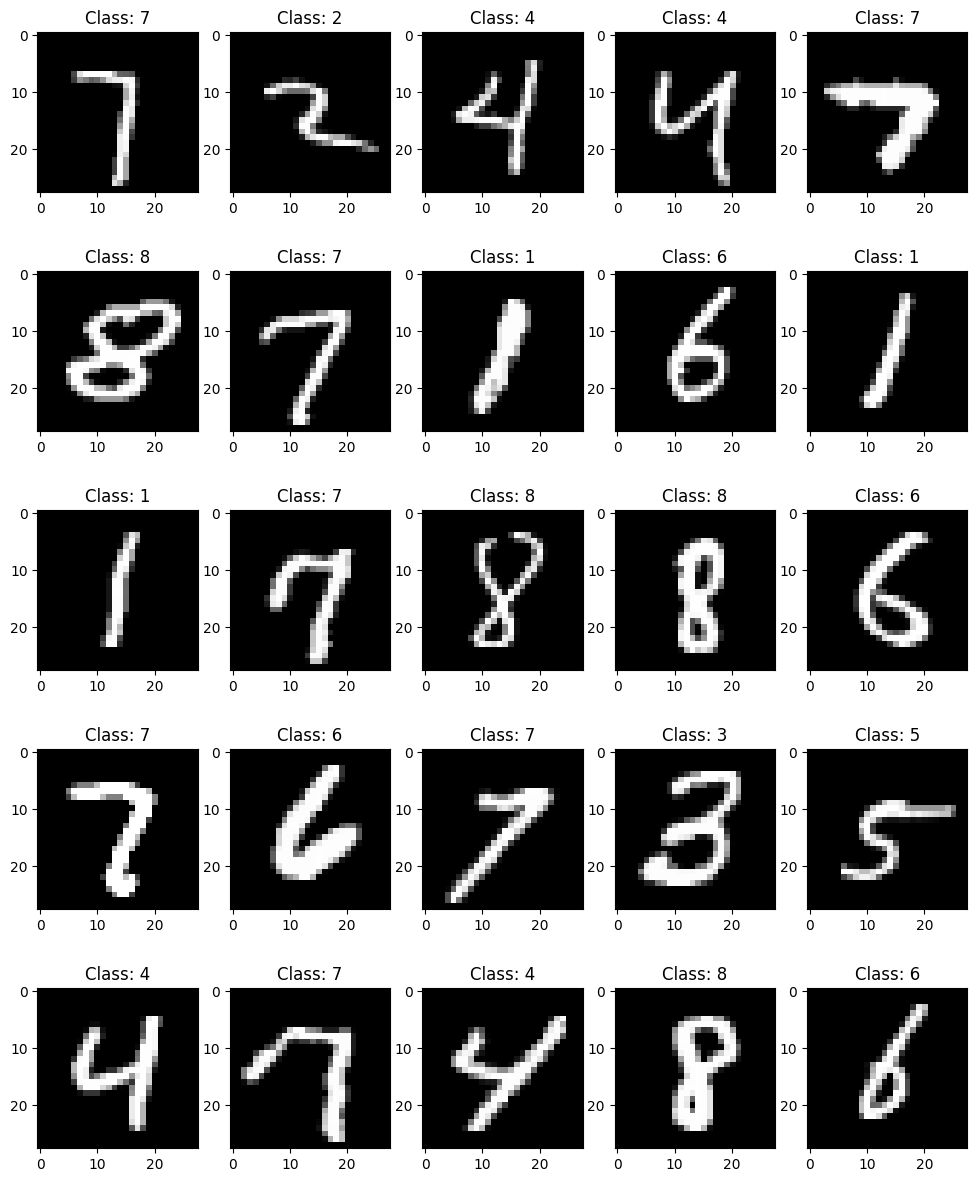

In [2]:
fig, ax = plt.subplots(nrows=5,ncols=5,figsize=(12,15))
for i in range(5):
  for j in range(5):
    d = np.random.randint(x_train.shape[0])
    ax[i,j].imshow(x_train[d].reshape(28,28),cmap='gray')
    ax[i,j].set_title(f"Class: {y_train[d]}")

## 2. Continuous-Label Regression Baseline

The digit class is first treated as a continuous numerical target. Predictions are rounded to the nearest integer and clipped to the valid class range from 0 to 9.

In [3]:
model = LinearRegression()
model.fit(x_train, np.float32(y_train))
pred = model.predict(x_test)
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.clip(np.round(pred),0,9)

print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,y_test)))
print('Confusion matrix')
print(confusion_matrix(y_test, pred_int))

Mean squared error = 3.146
Mean absolute error =  1.399
Accuracy = 0.2301
Confusion matrix
[[229 322 257 104  35  23   8   2   0   0]
 [  1 228 571 221  89  18   6   1   0   0]
 [ 37 121 247 312 206  86  19   0   4   0]
 [  7  44 197 321 275 100  42  12   9   3]
 [  0   0   5  36 195 340 251 116  36   3]
 [  0   3  21 118 253 288 145  35  18  11]
 [  3   3  24  70 158 272 268 116  42   2]
 [  0   1   7  27  71 135 246 289 152 100]
 [  0   1  10  27  99 194 274 229 101  39]
 [  0   1   5   8  25  60 141 313 321 135]]


The saved run produced an accuracy of **0.2300**, showing that numerical closeness between digit labels does not provide an effective representation of the multiclass classification objective.

## 3. One-Hot Target Representation

Each digit label is converted into a 10-dimensional one-hot vector. Linear regression predicts one score per class, and the class with the largest predicted value is selected.

In [4]:
def one_hot(y):
  return np.eye(np.max(y)+1)[y]

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)


In [5]:
model = LinearRegression()
model.fit(x_train, y_train_oh)
pred = model.predict(x_test)

print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test_oh)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test_oh)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,y_test)))
print('Confusion matrix')
print(confusion_matrix(y_test, pred_int))

Mean squared error = 0.038
Mean absolute error =  0.132
Accuracy = 0.8601
Confusion matrix
[[ 943    0    2    2    2    8   13    2    7    1]
 [   0 1107    2    2    3    1    5    1   14    0]
 [  18   53  812   26   17    0   43   20   38    5]
 [   4   18   21  884    5   16    9   20   22   11]
 [   0   22    7    0  880    5   11    2   11   44]
 [  23   18    3   75   23  660   23   13   38   16]
 [  18   10   10    0   21   17  875    0    7    0]
 [   5   42   15    6   26    0    1  882    0   51]
 [  14   46   11   31   28   41   15   11  758   19]
 [  16   11    3   17   79    0    1   78    4  800]]


The one-hot formulation increased the saved test accuracy to **0.8601**, a large improvement over directly regressing the numerical digit label.

## 4. Nonlinear Feature Expansion

Squared pixel intensities are added to the original pixel features while retaining the one-hot target representation.

In [6]:
model = LinearRegression()
model.fit(np.hstack((x_train,x_train**2)), y_train_oh)
pred = model.predict(np.hstack((x_test,x_test**2)))

print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test_oh)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test_oh)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,y_test)))
print('Confusion matrix')
print(confusion_matrix(y_test, pred_int))

Mean squared error = 0.033
Mean absolute error =  0.124
Accuracy = 0.8900
Confusion matrix
[[ 955    0    1    3    1    5    6    1    7    1]
 [   0 1117    3    3    2    1    5    1    3    0]
 [  16   28  853   19   15    2   30   18   46    5]
 [   6   14   20  881    4   15    9   22   29   10]
 [   1   16    8    2  884    2   12    2    7   48]
 [  20    7    3   50   21  718   21   13   22   17]
 [  18    3   10    0   20   20  879    0    8    0]
 [   7   29   14    9   22    0    1  897    2   47]
 [  13   15   10   27   11   25   10    4  842   17]
 [  12   13    3   15   39    0    0   38   15  874]]


The expanded representation produced a saved test accuracy of **0.8900**, improving on the one-hot linear baseline.

## 5. Results Summary

| Representation | Test Accuracy |
|---|---:|
| Continuous digit label + rounding | 0.2300 |
| One-hot target | 0.8601 |
| One-hot target + squared pixel features | 0.8900 |

## 6. Technical Takeaways

- Linear regression is not naturally designed for classification, but target representation strongly affects how it behaves in that setting.
- Treating categorical labels as continuous values imposes an artificial numerical ordering between classes.
- One-hot targets allow the model to produce a separate score for each class.
- Nonlinear feature expansion can improve performance while retaining the same linear estimator.
- Confusion matrices reveal class-specific error patterns that overall accuracy alone cannot show.